In [2]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# LinearRegressionModel (scratch __version__)
# Formula: y = a + bx
# a: bias (intercepter)
# b: weight (slope)
# x: imaginary number

weight = 0.7
bias = 0.3

# PyTorch RandomSeed
torch.manual_seed(42)

X = torch.arange(0, 10, 0.1).unsqueeze(dim=1)
y = bias + weight * X

In [4]:
split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

len(X_train), len(X_test), len(y_train), len(y_test)

(80, 20, 80, 20)

In [5]:
# LinearRegressionModel (PyTorch __version__)

class LinearRegressionModel(torch.nn.Module):
    def __init__(self):
        super().__init__()

        self.weights = torch.nn.Parameter(torch.randn(1,
                                                requires_grad=True,
                                                dtype=torch.float))
        self.bias = torch.nn.Parameter(torch.randn(1,
                                             requires_grad=True,
                                             dtype=torch.float))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
            return self.bias + self.weights * x

In [6]:
model = LinearRegressionModel()

In [7]:
with torch.inference_mode():
    y_pred = model(X_test)

In [8]:
X_train.shape, y_train.shape

(torch.Size([80, 1]), torch.Size([80, 1]))

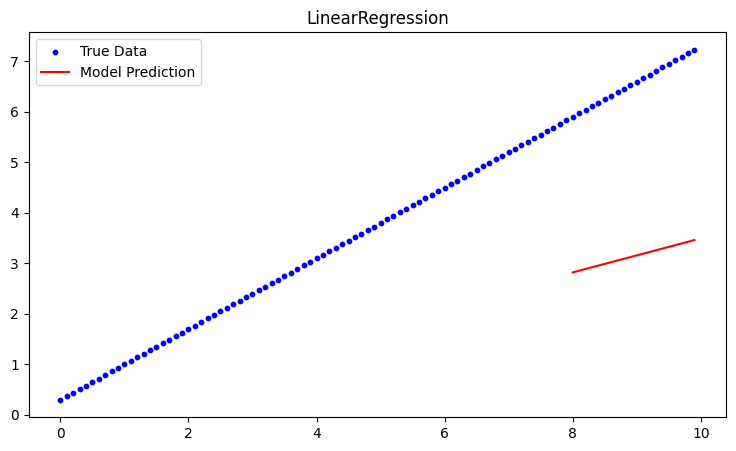

In [9]:
plt.figure(figsize=(9, 5))
plt.title("LinearRegression")
plt.scatter(X, y, label="True Data", c="blue", s=10)
plt.plot(X_test, y_pred, label="Model Prediction", c="red")
plt.legend()
plt.show()

In [11]:
## Loss Function & Optimizer

# L1Loss func
loss_func = torch.nn.L1Loss()

# Optimizer

optimizer = torch.optim.SGD(params = model.parameters(),
                           lr=0.01)

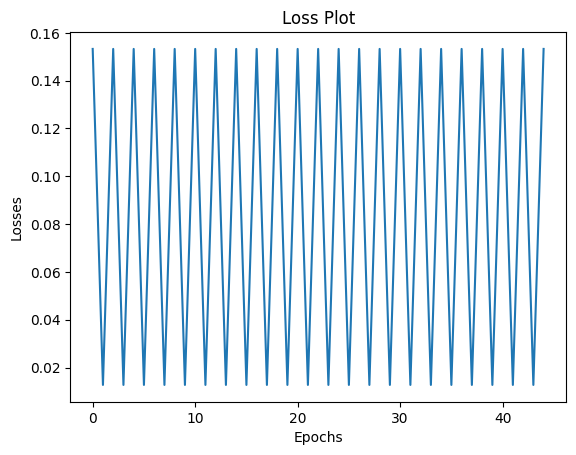

In [26]:
epochs = 45
losses = []

for epoch in range(epochs):
    model.train()

    y_pred = model(X_train)
    loss = loss_func(y_pred, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

plt.title("Loss Plot")
plt.plot(losses)
plt.xlabel("Epochs")
plt.ylabel("Losses")
plt.show()